In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Anonymize_Loan_Default_data.csv")
print(df.shape)
df = df.dropna(subset=['loan_amnt','repay_fail','dti','annual_inc','int_rate'])
df.shape
df.info()

(38480, 37)
<class 'pandas.core.frame.DataFrame'>
Index: 38478 entries, 0 to 38479
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              38478 non-null  int64  
 1   id                      38478 non-null  int64  
 2   member_id               38478 non-null  int64  
 3   loan_amnt               38478 non-null  float64
 4   funded_amnt             38478 non-null  float64
 5   funded_amnt_inv         38478 non-null  float64
 6   term                    38478 non-null  object 
 7   int_rate                38478 non-null  float64
 8   installment             38478 non-null  float64
 9   emp_length              37485 non-null  object 
 10  home_ownership          38478 non-null  object 
 11  annual_inc              38478 non-null  float64
 12  verification_status     38478 non-null  object 
 13  issue_d                 38478 non-null  object 
 14  loan_status             38478 n

In [3]:
df['risk_band'] = pd.qcut(df['dti'],q=3,labels=['low Risk','Medium Risk','High Risk'])

# calculating probability of loan default by risk band
pd_by_band = df.groupby('risk_band',observed=True)['repay_fail'].mean()
print(pd_by_band)
df['PD'] = df['risk_band'].map(pd_by_band)

risk_band
low Risk       0.132306
Medium Risk    0.152194
High Risk      0.169929
Name: repay_fail, dtype: float64


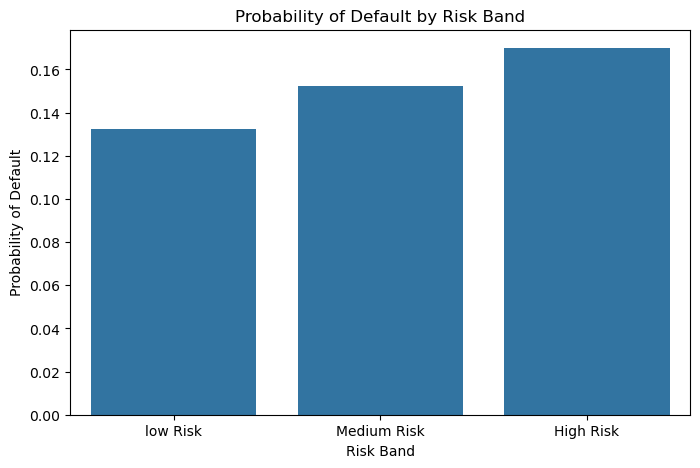

In [4]:
plt.figure(figsize=(8,5))

sns.barplot(x=pd_by_band.index,
            y=pd_by_band.values)

plt.title("Probability of Default by Risk Band")
plt.ylabel("Probability of Default")
plt.xlabel("Risk Band")

plt.show()

In [5]:
LGD_NORMAL = 0.6
LGD_STRESS = 0.6
SIMULATIONS = 5000

In [6]:
def simulate_portfolio(data, LGD, stress=False):

    losses = []

    for _ in range(SIMULATIONS):

        PD = data['PD'].copy()

        if stress:
            # Stress only high-risk borrowers
            high_risk_mask = PD > 0.15
            PD[high_risk_mask] *= 1.05

            # Cap probabilities at 1
            PD = np.minimum(PD, 1)

        defaults = np.random.binomial(1, PD)

        total_loss = np.sum(defaults * data['loan_amnt'] * LGD)

        losses.append(total_loss)

    return np.array(losses)

In [7]:
# print(df.dtypes)
df['PD'] = pd.to_numeric(df['PD'],errors='coerce')
normal_losses = simulate_portfolio(df, LGD_NORMAL,stress = False)
CAPITAL_BUFFER = np.percentile(normal_losses, 99)

In [8]:
stress_losses = simulate_portfolio(df,
                                   LGD_STRESS,
                                   stress = True)

In [9]:
def print_metrics(losses, name):

    print(f"\n==== {name} Scenario ====")

    print("Expected Loss:", round(np.mean(losses),2))
    print("95% VaR:", round(np.percentile(losses,95),2))
    print("99% VaR:", round(np.percentile(losses,99),2))
    print("Capital Breach Probability:",
          round(np.mean(losses > CAPITAL_BUFFER),4))


print_metrics(normal_losses, "Normal")
print_metrics(stress_losses, "Stress")


==== Normal Scenario ====
Expected Loss: 38940603.98
95% VaR: 39841269.75
99% VaR: 40236847.35
Capital Breach Probability: 0.01

==== Stress Scenario ====
Expected Loss: 40366644.72
95% VaR: 41310618.0
99% VaR: 41704010.25
Capital Breach Probability: 0.5854


In [10]:
policy_df = df[df['risk_band'] != 'High Risk']

policy_losses = simulate_portfolio(policy_df, LGD_NORMAL)

print_metrics(policy_losses, "Policy Tightened")

approval_drop = 1 - (len(policy_df)/len(df))
print("Loan Approval Reduction:", round(approval_drop,4))


==== Policy Tightened Scenario ====
Expected Loss: 24049124.55
95% VaR: 24777871.5
99% VaR: 25158354.0
Capital Breach Probability: 0.0
Loan Approval Reduction: 0.3333


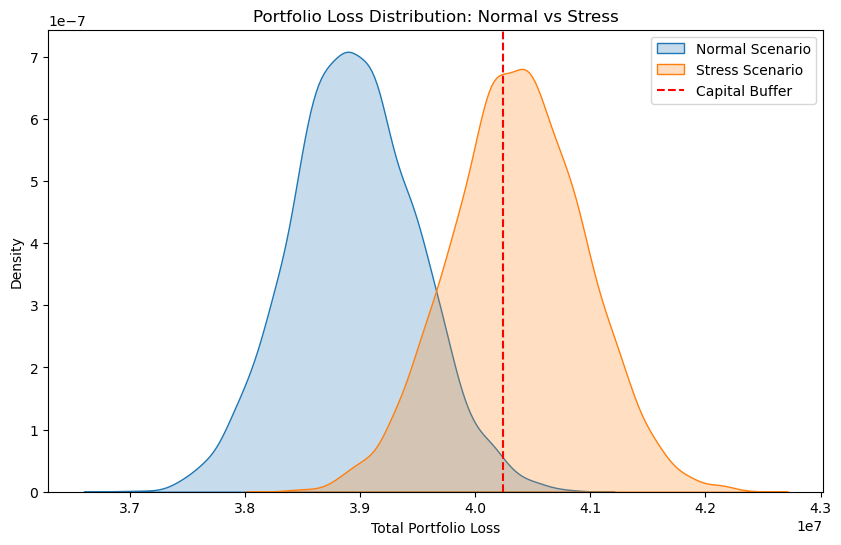

In [11]:
plt.figure(figsize=(10,6))

sns.kdeplot(normal_losses, label="Normal Scenario", fill=True)
sns.kdeplot(stress_losses, label="Stress Scenario", fill=True)

plt.axvline(CAPITAL_BUFFER, color='red', linestyle='--', label="Capital Buffer")

plt.title("Portfolio Loss Distribution: Normal vs Stress")
plt.xlabel("Total Portfolio Loss")
plt.ylabel("Density")
plt.legend()

plt.show()

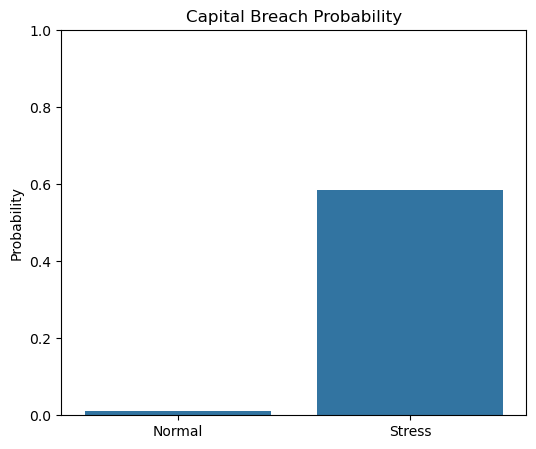

In [12]:
normal_breach = np.mean(normal_losses > CAPITAL_BUFFER)
stress_breach = np.mean(stress_losses > CAPITAL_BUFFER)

plt.figure(figsize=(6,5))

sns.barplot(x=["Normal", "Stress"],
            y=[normal_breach, stress_breach])

plt.title("Capital Breach Probability")
plt.ylabel("Probability")
plt.ylim(0,1)

plt.show()

In [13]:
print("Normal Breach:", normal_breach)
print("Stress Breach:", stress_breach)

print("Normal 95% VaR:", np.percentile(normal_losses, 95))
print("Stress 95% VaR:", np.percentile(stress_losses, 95))

Normal Breach: 0.01
Stress Breach: 0.5854
Normal 95% VaR: 39841269.75
Stress 95% VaR: 41310618.0


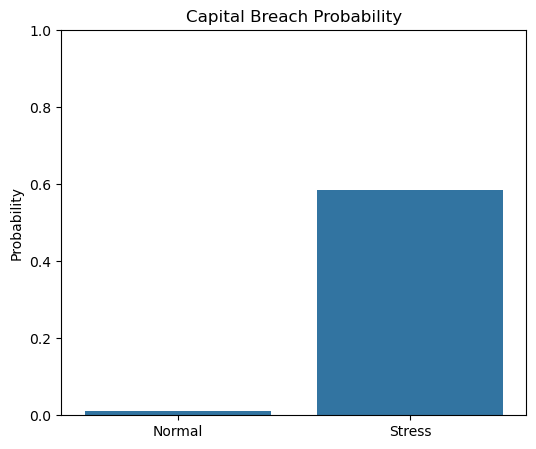

In [14]:
normal_breach = np.mean(normal_losses > CAPITAL_BUFFER)
stress_breach = np.mean(stress_losses > CAPITAL_BUFFER)

plt.figure(figsize=(6,5))

sns.barplot(x=["Normal", "Stress"],
            y=[normal_breach, stress_breach])

plt.title("Capital Breach Probability")
plt.ylabel("Probability")
plt.ylim(0,1)

plt.show()